<h1>Train — InceptionNet v3</h1>

Trains and evaluates InceptionNet v3 using the tuned hyperparameters from `ARCH_HYPERPARAMS["inception_v3"]`, then saves its results and weights to disk for the results notebook.

In [1]:
from wwtw_utils import *

Using device: cuda
Test set ID (derived from DATASET_ROOT): Waterval
Classes found (4): ['Dysfunctional', 'Empty', 'Functional', 'Scum']
Train: 1789 | Val: 434 | Test: 284


## Build dataloaders + class weights for this architecture

In [2]:
cfg = ARCH_HYPERPARAMS["inception_v3"]

# The tuned batch size (cfg["batch_size"]) can be too large to fit in GPU
# memory for a deeper model like this one, even though it fit fine for
# whichever model the tuning trials actually ran on. Rather than hard-coding
# a smaller batch size (and drifting from the tuned hyperparameters), cap the
# *actual* loader batch size at MICRO_BATCH_CAP and use gradient accumulation
# in train_model to still reach the tuned effective batch size.
micro_batch = min(cfg["batch_size"], MICRO_BATCH_CAP)
accum_steps = max(1, round(cfg["batch_size"] / micro_batch))
print(f"InceptionNet v3: micro batch = {micro_batch}, accumulation steps = {accum_steps} "
      f"(effective batch size ≈ {micro_batch * accum_steps}, tuned value = {cfg['batch_size']})")

# This backbone gets its own dataloaders — its own (capped) batch size, and
# (for InceptionNet v3) its own image size.
train_ds_arch, val_ds_arch, test_ds_arch, train_loader_arch, val_loader_arch, test_loader_arch = \
    get_dataloaders(cfg["img_size"], micro_batch)

class_weights_arch = make_class_weights(train_ds_arch)

InceptionNet v3: micro batch = 16, accumulation steps = 1 (effective batch size ≈ 16, tuned value = 17)


## Define the model

In [3]:
# ---------------------------------------------------------
# Define the CNN (Transfer Learning with InceptionNet v3)
# ---------------------------------------------------------
model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1, aux_logits=True)

in_f = model.fc.in_features
model.fc = build_classifier_head(in_f, cfg["hidden_layers"], cfg["neurons"], num_classes)

# The auxiliary classifier (used only during training, see run_epoch in
# wwtw_utils.py) also needs its output layer resized to our number of classes.
in_f_aux = model.AuxLogits.fc.in_features
model.AuxLogits.fc = nn.Linear(in_f_aux, num_classes)

model = model.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights_arch)
optimizer = optim.Adam(
    model.parameters(),
    lr=cfg["lr"],
    betas=(cfg["beta1"], ADAM_BETA2),
    weight_decay=WEIGHT_DECAY,
)
# Step-based decay: LR x0.1 every Es epochs, per the Bayesian-optimized step size.
scheduler = StepLR(optimizer, step_size=cfg["step_size"], gamma=0.1)

## Train, then plot training curves

[InceptionNet v3] Epoch   1/100 | LR: 1.43e-04 | train loss 1.3789 acc 0.559 | val loss 0.6438 acc 0.740 *


[InceptionNet v3] Epoch   2/100 | LR: 1.43e-04 | train loss 0.9612 acc 0.717 | val loss 0.7211 acc 0.735


[InceptionNet v3] Epoch   3/100 | LR: 1.43e-04 | train loss 0.8351 acc 0.767 | val loss 0.4619 acc 0.800 *


[InceptionNet v3] Epoch   4/100 | LR: 1.43e-04 | train loss 0.6759 acc 0.799 | val loss 0.5275 acc 0.793


[InceptionNet v3] Epoch   5/100 | LR: 1.43e-04 | train loss 0.6343 acc 0.832 | val loss 0.5154 acc 0.834


...

[InceptionNet v3] Epoch   9/100 | LR: 1.43e-04 | train loss 0.4323 acc 0.875 | val loss 0.5663 acc 0.859


[InceptionNet v3] Epoch  10/100 | LR: 1.43e-04 | train loss 0.4029 acc 0.877 | val loss 0.5856 acc 0.834


[InceptionNet v3] Epoch  11/100 | LR: 1.43e-04 | train loss 0.3444 acc 0.906 | val loss 0.6421 acc 0.834


[InceptionNet v3] Epoch  12/100 | LR: 1.43e-04 | train loss 0.3347 acc 0.903 | val loss 0.5218 acc 0.850


[InceptionNet v3] Epoch  13/100 | LR: 1.43e-04 | train loss 0.3289 acc 0.914 | val loss 0.4704 acc 0.846

[InceptionNet v3] No val loss improvement for 10 epochs — stopping early at epoch 13.

[InceptionNet v3] Restored best checkpoint (val loss = 0.4619)


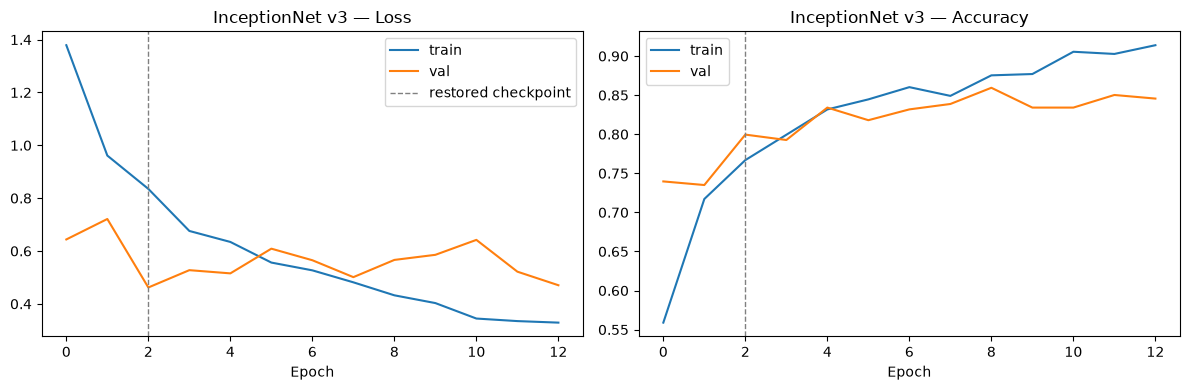

In [4]:
history = train_model(
    model, train_loader_arch, val_loader_arch, optimizer, scheduler,
    criterion, EPOCHS, EARLY_STOP_PATIENCE, "InceptionNet v3", is_inception=True,
    accum_steps=accum_steps,
)
plot_training_curves(history, "InceptionNet v3")

## Evaluate on the test set

[InceptionNet v3] Test accuracy: 0.799


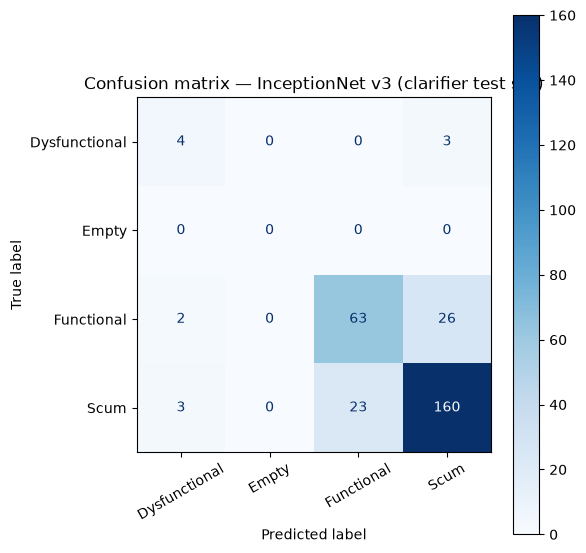

               precision    recall  f1-score   support

Dysfunctional      0.444     0.571     0.500         7
        Empty      0.000     0.000     0.000         0
   Functional      0.733     0.692     0.712        91
         Scum      0.847     0.860     0.853       186

     accuracy                          0.799       284
    macro avg      0.506     0.531     0.516       284
 weighted avg      0.800     0.799     0.799       284

  [warn] 'Empty' has 0 examples in this test set — AUC undefined, skipping.


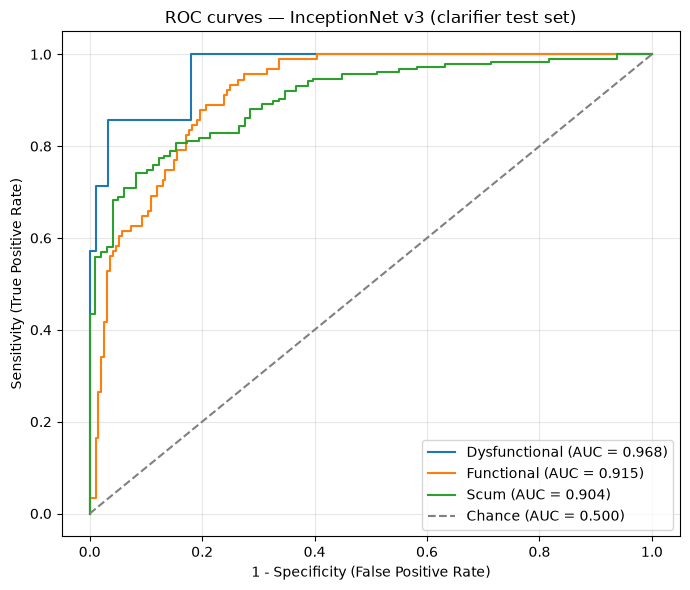

AUC (area under ROC curve) per class:
  Dysfunctional  : 0.968
  Empty          : undefined (0 examples)
  Functional     : 0.915
  Scum           : 0.904

Mean AUC (over 3/4 classes with test examples): 0.929


(np.float64(0.7992957746478874),
 {'Dysfunctional': 0.9680247550283652,
  'Empty': nan,
  'Functional': 0.9147070546034276,
  'Scum': 0.9041035769146368})

In [5]:
evaluate_and_record(
    model, test_loader_arch, "InceptionNet v3", history,
    img_size=cfg["img_size"], hidden_layers=cfg["hidden_layers"], neurons=cfg["neurons"],
)

## Save results + model weights to disk

In [6]:
save_result("InceptionNet v3", "inception_v3")

Saved results to ../results/results_clarifier_inception_v3_Waterval.pkl


Saved model weights to ../models/clarifier_inception_v3_cnn.pt
